In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize
from scipy.stats import norm, t, norminvgauss
import warnings
from scipy.integrate import IntegrationWarning

#Filter out the specific IntegrationWarning from scipy.stats
warnings.filterwarnings("ignore", category=IntegrationWarning)

plt.rcParams["figure.figsize"] = (8, 5)


Bitcoin log-return summary statistics:
Mean: 0.0007493106865785292
Std Dev: 0.035673391143803475
Skewness: -0.9791117437877443
Kurtosis: 17.049283452489043

Shapiro–Wilk test:
Statistic: 0.9086171206080189 p-value: 1.1243343569196625e-36


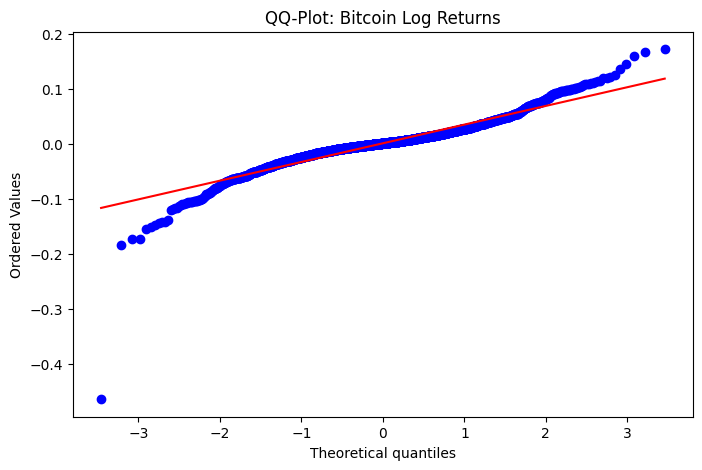

In [3]:
# Section 1: Bitcoin Log Return Distribution Analysis

btc = pd.read_csv('bitcoin_data.csv')

btc['daily_log_returns'] = np.log(btc['Adj Close'] / btc['Adj Close'].shift(1))
daily_log_returns = btc['daily_log_returns'].dropna()

print("\nBitcoin log-return summary statistics:")
print("Mean:", daily_log_returns.mean())
print("Std Dev:", daily_log_returns.std())
print("Skewness:", stats.skew(daily_log_returns))
print("Kurtosis:", stats.kurtosis(daily_log_returns, fisher=False))

shapiro_stat, shapiro_p = stats.shapiro(daily_log_returns)
print("\nShapiro–Wilk test:")
print("Statistic:", shapiro_stat, "p-value:", shapiro_p)

stats.probplot(daily_log_returns, dist="norm", plot=plt)
plt.title("QQ-Plot: Bitcoin Log Returns")
plt.show()

Candidate distribution 1: Normal Distribution

Normal parameters (μ, σ): (0.0007, 0.0357)

Kolmogorov–Smirnov Normal p-value: 4.0437e-21


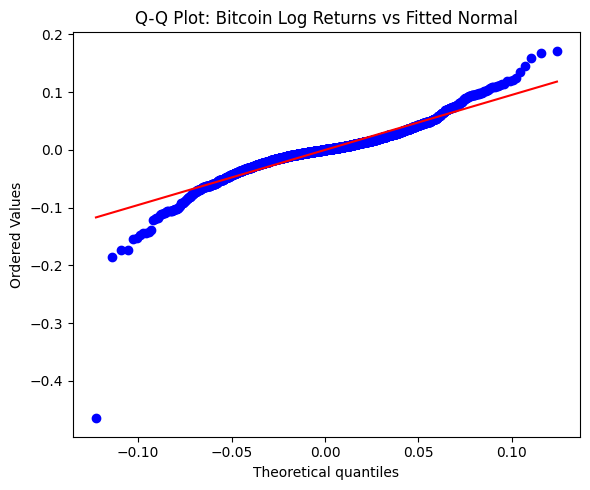

Candidate distribution 2: Student’s t Distribution

Student-t parameters (ν, μ, σ): (2.4056, 0.0010, 0.0200)

Kolmogorov–Smirnov Student-t p-value: 1.0808e-01


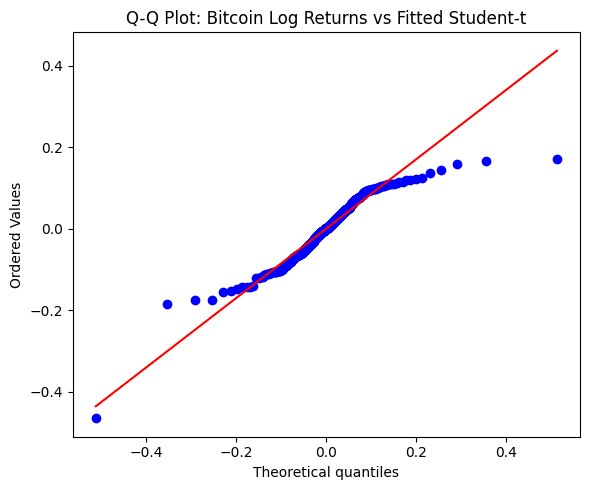

Candidate distribution 3: Normal Inverse Gaussian (NIG) Distribution

NIG parameters (α, β, μ, δ): (0.3299, -0.0045, 0.0010, 0.0208)

Kolmogorov–Smirnov NIG p-value: 5.3718e-01


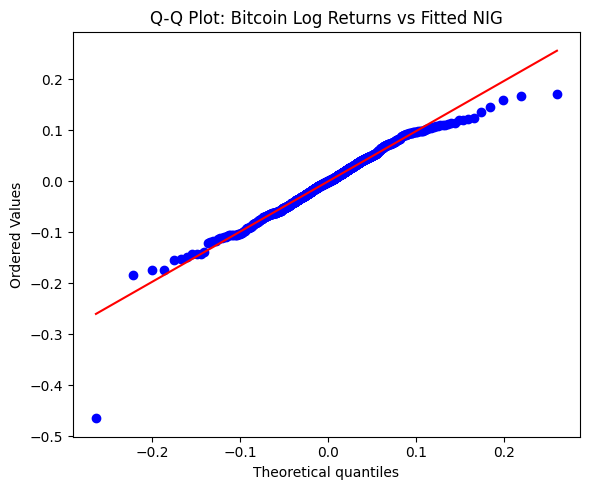

In [4]:
# Section 2: Distribution Fitting (MLE + KS Test)

print('Candidate distribution 1: Normal Distribution\n')
params_norm = norm.fit(daily_log_returns)
print(f"Normal parameters (μ, σ): ({params_norm[0]:.4f}, {params_norm[1]:.4f})")
ks_norm = stats.kstest(daily_log_returns, "norm", args=params_norm)
print(f"\nKolmogorov–Smirnov Normal p-value: {ks_norm.pvalue:.4e}")

#Create Q-Q plot for Normal Distribution
plt.figure(figsize=(6, 5))
stats.probplot(daily_log_returns, dist="norm", sparams=(params_norm[0], params_norm[1]), plot=plt)
plt.title("Q-Q Plot: Bitcoin Log Returns vs Fitted Normal")
plt.tight_layout()
plt.show()

print('Candidate distribution 2: Student’s t Distribution\n')
params_t = t.fit(daily_log_returns)
print(f"Student-t parameters (ν, μ, σ): ({params_t[0]:.4f}, {params_t[1]:.4f}, {params_t[2]:.4f})")
ks_t = stats.kstest(daily_log_returns, "t", args=params_t)
print(f"\nKolmogorov–Smirnov Student-t p-value: {ks_t.pvalue:.4e}")

#Create Q-Q plot for Student-t Distribution
plt.figure(figsize=(6, 5))
stats.probplot(daily_log_returns, dist=stats.t, sparams=(params_t[0], params_t[1], params_t[2]), plot=plt)
plt.title("Q-Q Plot: Bitcoin Log Returns vs Fitted Student-t")
plt.tight_layout()
plt.show()

print('Candidate distribution 3: Normal Inverse Gaussian (NIG) Distribution\n')
params_nig = norminvgauss.fit(daily_log_returns)
print(f"NIG parameters (α, β, μ, δ): ({params_nig[0]:.4f}, {params_nig[1]:.4f}, {params_nig[2]:.4f}, {params_nig[3]:.4f})")
ks_nig = stats.kstest(daily_log_returns, "norminvgauss", args=params_nig)
print(f"\nKolmogorov–Smirnov NIG p-value: {ks_nig.pvalue:.4e}")

#Create Q-Q plot for NIG Distribution
plt.figure(figsize=(6, 5))
stats.probplot(daily_log_returns, dist=stats.norminvgauss, sparams=(params_nig[0], params_nig[1], params_nig[2], params_nig[3]), plot=plt)
plt.title("Q-Q Plot: Bitcoin Log Returns vs Fitted NIG")
plt.tight_layout()
plt.show()

In [5]:
# Section 3: VaR and CVaR Estimation

def historical_var_cvar(returns, alpha):
    var = np.quantile(returns, 1 - alpha)
    cvar = returns[returns <= var].mean()
    return var, cvar

levels = [0.95, 0.99] #confidence levels

print("\nHistorical VaR and CVaR:")
for confidence_level in levels:
    significance_level = 1 - confidence_level
    v, c = historical_var_cvar(daily_log_returns, confidence_level)
    print(f"{significance_level:.0%} significance level: VaR={v:.6f}, CVaR={c:.6f}")

print("\nParametric NIG VaR and CVaR:")
for confidence_level in levels:
    significance_level = 1 - confidence_level
    var_p = norminvgauss.ppf(1 - confidence_level, params_nig[0], params_nig[1], loc=params_nig[2], scale=params_nig[3])
    cvar_p = norminvgauss.expect(
        lambda x: x, args=(params_nig[0], params_nig[1]),
        loc=params_nig[2], scale=params_nig[3],
        lb=-np.inf, ub=var_p
    ) / (1 - confidence_level)
    print(f"{significance_level:.0%} significance level: VaR={var_p:.6f}, CVaR={cvar_p:.6f}")


Historical VaR and CVaR:
5% significance level: VaR=-0.055894, CVaR=-0.086321
1% significance level: VaR=-0.104811, CVaR=-0.141753

Parametric NIG VaR and CVaR:
5% significance level: VaR=-0.053374, CVaR=-0.087277
1% significance level: VaR=-0.106871, CVaR=-0.147899



Recovered S&P 500 index level S0: 6114.65
Forward price (F) from Put-Call Parity: 6124.35


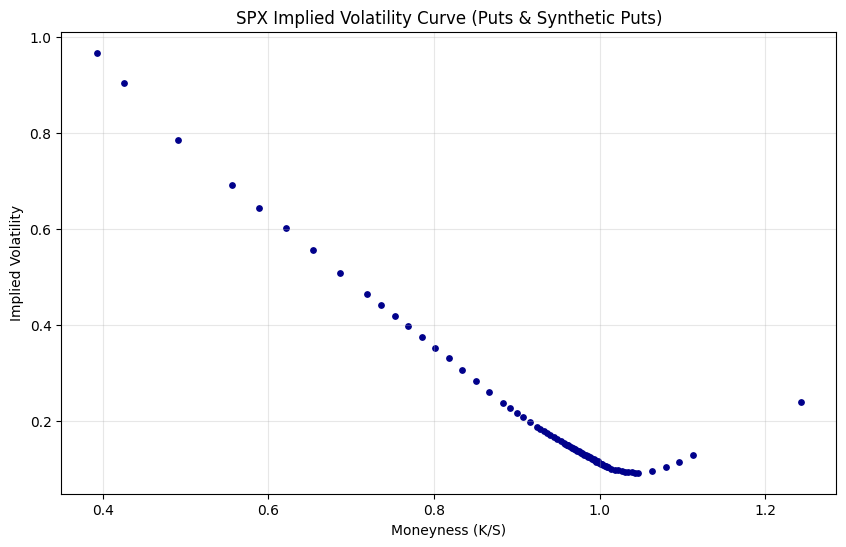

In [6]:
# Section 4: SPX Implied Volatility Curve Construction

opts = pd.read_csv('spx-options-exp-2025-03-13-weekly.csv')
opts.columns = [c.strip() for c in opts.columns]

#Ensure numeric types
cols_to_fix = ['Strike', 'Bid', 'Ask', 'Mid', 'Volume', 'Open Int', 'Moneyness']
for col in cols_to_fix:
    if col in opts.columns:
        opts[col] = pd.to_numeric(opts[col].astype(str).str.replace(r'[%,+]', '', regex=True), errors='coerce')

#Set Current Index Price (S0) using reference logic
#S0 = K / (1 - Moneyness_provided)
first_row = opts.iloc[0]
S0 = first_row['Strike'] / (1 - (first_row['Moneyness'] / 100))
print(f"\nRecovered S&P 500 index level S0: {S0:.2f}")

#Update Moneyness to K/S for the rest of the analysis
opts['Moneyness_KS'] = opts['Strike'] / S0

#Parameters
T = 30 / 365
r = 0.0431

#Calculate Forward Price (F) using Put-Call Parity
# Find ATM options (Moneyness K/S closest to 1)
atm_idx = (opts['Moneyness_KS'] - 1).abs().idxmin()
K_atm = opts.loc[atm_idx, 'Strike']

#Get ATM Call and Put prices
atm_call_price = opts[(opts['Strike'] == K_atm) & (opts['Type'] == 'Call')]['Mid'].values[0]
atm_put_price = opts[(opts['Strike'] == K_atm) & (opts['Type'] == 'Put')]['Mid'].values[0]

#F = (C - P + K*exp(-rT)) * exp(rT)
F = (atm_call_price - atm_put_price + K_atm * np.exp(-r * T)) * np.exp(r * T)
print(f"Forward price (F) from Put-Call Parity: {F:.2f}")

#Filter Liquid Options
liquid_opts = opts[(opts['Open Int'] > 0) | (opts['Volume'] > 0)].copy()

#Separate and Create Synthetic Puts
#We want a curve based on Puts. OTM Puts (K < S0) and Synthetic Puts from OTM Calls (K > S0)
real_puts = liquid_opts[(liquid_opts['Type'] == 'Put') & (liquid_opts['Strike'] <= S0)].copy()
otm_calls = liquid_opts[(liquid_opts['Type'] == 'Call') & (liquid_opts['Strike'] > S0)].copy()

#P = C - F*exp(-rT) + K*exp(-rT)
otm_calls['Mid_Synthetic'] = (otm_calls['Mid'] - F * np.exp(-r * T) + otm_calls['Strike'] * np.exp(-r * T))
otm_calls['Type'] = 'Put'
otm_calls['Mid'] = otm_calls['Mid_Synthetic']

#Combine into a unified Put dataset
put_curve_data = pd.concat([real_puts, otm_calls], ignore_index=True).sort_values('Strike')

#Implied Volatility via Bisection
def iv_bisection(F, K, T, r, market_price, option_type='Put'):
    sigma_low, sigma_high = 0.001, 5.0
    for _ in range(100):
        sigma_mid = (sigma_low + sigma_high) / 2
        #Use the black_scholes logic
        d1 = (np.log(F/K) + 0.5 * sigma_mid**2 * T) / (sigma_mid * np.sqrt(T))
        d2 = d1 - sigma_mid * np.sqrt(T)
        price = K*np.exp(-r*T)*norm.cdf(-d2) - F*np.exp(-r*T)*norm.cdf(-d1)

        if abs(price - market_price) < 1e-5: return sigma_mid
        if price > market_price: sigma_high = sigma_mid
        else: sigma_low = sigma_mid
    return sigma_mid

put_curve_data['IV_calculated'] = put_curve_data.apply(
    lambda row: iv_bisection(F, row['Strike'], T, r, row['Mid']) if row['Mid'] > 0 else np.nan, axis=1
)


plt.figure(figsize=(10, 6))
plt.scatter(put_curve_data['Moneyness_KS'], put_curve_data['IV_calculated'], color='darkblue', s=15)
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('SPX Implied Volatility Curve (Puts & Synthetic Puts)')
plt.grid(True, alpha=0.3)
plt.show()

------------------------------
Calculated VIX: 14.30%
Reported CBOE VIX: 15.10%
Difference: 0.80
------------------------------


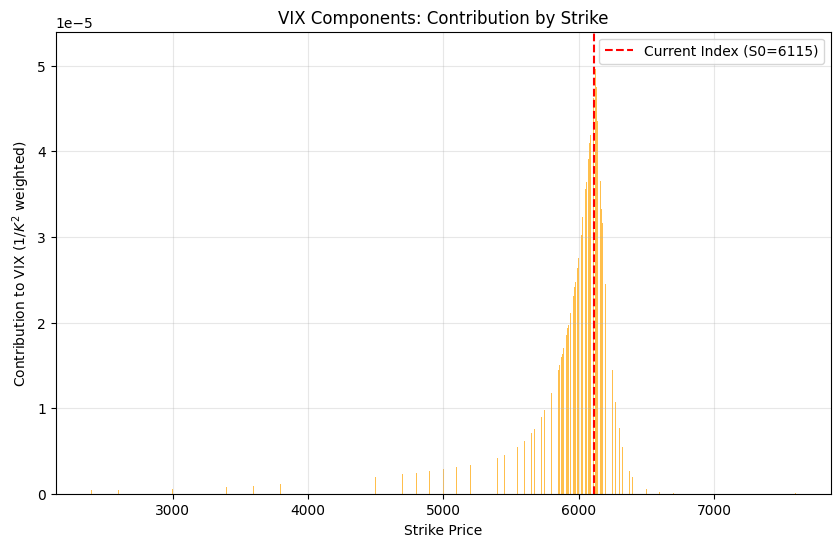

In [7]:
# Section 5: VIX Replication

#Define the contribution function
def calculate_option_contribution(row, T, r):
    K = row['Strike']
    Q = row['Mid']  #Using mid price
    #Formula: (2/T) * e^(rT) * Q / K^2
    return (2/T) * np.exp(r*T) * Q / (K**2)

#Initialize variables
sigma_squared = 0

#Combine OTM puts and calls
otm_puts_vix = liquid_opts[(liquid_opts['Type'] == 'Put') & (liquid_opts['Strike'] < S0)].copy()
otm_calls_vix = liquid_opts[(liquid_opts['Type'] == 'Call') & (liquid_opts['Strike'] > S0)].copy()

all_options = pd.concat([otm_puts_vix, otm_calls_vix]).sort_values('Strike').reset_index(drop=True)

#Calculate contribution using the mid-range loop
for i in range(1, len(all_options) - 1):
    current_option = all_options.iloc[i]
    delta_K = (all_options.iloc[i+1]['Strike'] - all_options.iloc[i-1]['Strike']) / 2

    contribution = delta_K * calculate_option_contribution(current_option, T, r)
    sigma_squared += contribution

#Find F_minus: strike immediately below spot (S0)
F_minus = all_options[all_options['Strike'] < S0]['Strike'].max()

#Apply final adjustment and VIX calculation
sigma_squared -= (F / F_minus - 1)**2 / T
VIX_calc = 100 * np.sqrt(sigma_squared)

print("-" * 30)
print(f"Calculated VIX: {VIX_calc:.2f}%")
print(f"Reported CBOE VIX: 15.10%")
print(f"Difference: {abs(VIX_calc - 15.10):.2f}")
print("-" * 30)

#Plot VIX Components (Visualizing the Weighting)
all_options['Contribution'] = all_options.apply(lambda x: calculate_option_contribution(x, T, r), axis=1)

plt.figure(figsize=(10, 6))
plt.bar(all_options['Strike'], all_options['Contribution'], width=5, color='orange', alpha=0.7)
plt.axvline(S0, color='red', linestyle='--', label=f'Current Index (S0={S0:.0f})')
plt.xlabel('Strike Price')
plt.ylabel('Contribution to VIX ($1/K^2$ weighted)')
plt.title('VIX Components: Contribution by Strike')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Section 6: Risk-Neutral Moments via BKM Framework

#BKM Weighting Functions
def calculate_quad_contract(row, S0):
    K, Q = row['Strike'], row['Mid']
    return 2 * (1 - np.log(K/S0)) / (K**2) * Q

def calculate_cubic_contract(row, S0):
    K, Q = row['Strike'], row['Mid']
    return (6 * np.log(K/S0) - 3 * np.log(K/S0)**2) / (K**2) * Q

def calculate_quartic_contract(row, S0):
    K, Q = row['Strike'], row['Mid']
    return (12 * np.log(K/S0)**2 - 4 * np.log(K/S0)**3) / (K**2) * Q


V, W, X = 0, 0, 0
for i in range(1, len(all_options) - 1):
    curr = all_options.iloc[i]
    delta_K = (all_options.iloc[i+1]['Strike'] - all_options.iloc[i-1]['Strike']) / 2

    V += delta_K * calculate_quad_contract(curr, S0)
    W += delta_K * calculate_cubic_contract(curr, S0)
    X += delta_K * calculate_quartic_contract(curr, S0)

#Calculate Final Risk-Neutral Moments
e_rT = np.exp(r * T)
#The mean of log returns under Q
mu_Q = e_rT - 1 - (e_rT * V / 2.) - (e_rT * W / 6.) - (e_rT * X / 24.)
#Variance and standardized Volatility, Skewness, Kurtosis
var_Q = (e_rT * V - mu_Q**2)
vol_Q = np.sqrt(var_Q)
skew_Q = (e_rT * W - 3 * mu_Q * e_rT * V + 2 * mu_Q**3) / (vol_Q**3)
kurt_Q = (e_rT * X - 4 * mu_Q * e_rT * W + 6 * mu_Q**2 * e_rT * V - 3 * mu_Q**4) / (vol_Q**4)

print("\n--- Risk-Neutral Moments (BKM) ---")
print(f"Mean (RN): {mu_Q:.6f}")
print(f"Std Dev (RN): {vol_Q:.6f}")
print(f"Skewness (RN): {skew_Q:.4f}")
print(f"Kurtosis (RN): {kurt_Q:.4f}")

#Comparison of Real-World (scaled to Monthly) vs Risk-Neutral
#Scaling daily stats to match the 30-day (T) option maturity
rw_daily_mean = daily_log_returns.mean()
rw_daily_std = daily_log_returns.std()

rw_monthly_mean = rw_daily_mean * 21 #Approximate trading days in a month
rw_monthly_std = rw_daily_std * np.sqrt(21)
rw_skew = stats.skew(daily_log_returns)
rw_kurt = stats.kurtosis(daily_log_returns, fisher=False)

comparison_df = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Skewness', 'Kurtosis'],
    'Real-World (Monthly)': [rw_monthly_mean, rw_monthly_std, rw_skew, rw_kurt],
    'Risk-Neutral (30-day)': [mu_Q, vol_Q, skew_Q, kurt_Q]
})
print("\nComparison of Distributions:")
print(comparison_df)


--- Risk-Neutral Moments (BKM) ---
Mean (RN): 0.002704
Std Dev (RN): 0.042733
Skewness (RN): -6.9267
Kurtosis (RN): 117.9737

Comparison of Distributions:
     Metric  Real-World (Monthly)  Risk-Neutral (30-day)
0      Mean              0.015736               0.002704
1   Std Dev              0.163476               0.042733
2  Skewness             -0.979112              -6.926687
3  Kurtosis             17.049283             117.973726



Starting Global Optimization (NIG)...
Optimized Parameters [alpha, beta, delta, mu]: [ 3.47097615e+01 -8.17123854e-01  2.51431653e-02  2.41051547e-02]


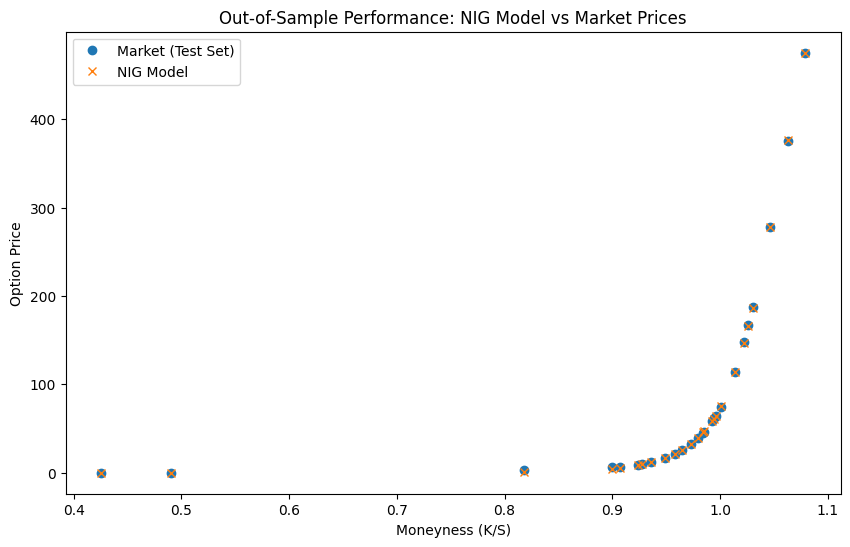

In [9]:
# Section 7: NIG Calibration to SPX Options (Risk-Neutral)

from scipy.optimize import differential_evolution

#Monte Carlo Path Generator for NIG
def nig_monte_carlo_base(S0, T, r, n_paths, params, U, Z, W):
    alpha, beta, delta, mu = params
    #Characteristic of Inverse Gaussian
    a, b = alpha * delta, beta * delta
    mu_ig = 1. / np.sqrt(a**2 - b**2)

    y = Z**2
    x = mu_ig + mu_ig**2 * y / 2. - (mu_ig / 2) * np.sqrt(4 * mu_ig * y + mu_ig**2 * y**2)
    c = mu_ig / (mu_ig + x)
    accept = U <= c
    x[~accept] = mu_ig**2 / x[~accept]

    #Stock price evolution
    X = mu + delta * (beta * x + np.sqrt(x) * W)
    return S0 * np.exp(X)

#Objective Function: MSE of market prices
def nig_objective(params, options_data, S0, r, T, n_paths, U, Z, W):
    #Constraint: alpha > |beta|
    if params[0] <= abs(params[1]): return 1e10

    ST = nig_monte_carlo_base(S0, T, r, n_paths, params, U, Z, W)
    model_prices = []
    for _, row in options_data.iterrows():
        K = row['Strike']
        #Pricing Puts
        price = np.exp(-r*T) * np.mean(np.maximum(K - ST, 0))
        model_prices.append(price)

    return np.mean((np.array(model_prices) - options_data['Mid'].values)**2)

#Setup and Run Calibration
n_paths = 50000
np.random.seed(42)
U = np.random.uniform(0, 1, n_paths)
Z = np.random.normal(0, 1, n_paths)
W = np.random.normal(0, 1, n_paths)

#Bounds for [alpha, beta, delta, mu]
bounds = [(5, 50), (-20, 20), (0.001, 0.5), (-0.1, 0.1)]

#Split Data (70% Train, 30% Test)
train_data = put_curve_data.sample(frac=0.7, random_state=42).sort_values('Strike')
test_data = put_curve_data.drop(train_data.index).sort_values('Strike')

print("\nStarting Global Optimization (NIG)...")
result = differential_evolution(
    nig_objective, bounds,
    args=(train_data, S0, r, T, n_paths, U, Z, W),
    maxiter=50, popsize=15, seed=42
)

nig_opt_params = result.x
print(f"Optimized Parameters [alpha, beta, delta, mu]: {nig_opt_params}")

#Final Comparison Plot
ST_final = nig_monte_carlo_base(S0, T, r, n_paths, nig_opt_params, U, Z, W)
test_prices = [np.exp(-r*T) * np.mean(np.maximum(K - ST_final, 0)) for K in test_data['Strike']]

plt.figure(figsize=(10, 6))
plt.plot(test_data['Moneyness_KS'], test_data['Mid'], 'o', label='Market (Test Set)')
plt.plot(test_data['Moneyness_KS'], test_prices, 'x', label='NIG Model')
plt.title("Out-of-Sample Performance: NIG Model vs Market Prices")
plt.xlabel("Moneyness (K/S)")
plt.ylabel("Option Price")
plt.legend()
plt.show()